# Standalone PINN Model

This notebook trains a single Physics-Informed Neural Network (PINN) on the circuit dataset, without K-fold cross validation or other comparison models. It reports regression, classification, and physics-consistency performance on a hold-out test split.

In [1]:
import os
import random
import time
import warnings

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')

def set_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    print(f'Random seeds set to {seed}.')

set_seeds(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Random seeds set to 42.
Using device: cpu


In [2]:
file_path = '../Data/FINAL_4CLASSES.csv'

if not os.path.exists(file_path):
    raise FileNotFoundError(f'{file_path} not found. Please make sure the dataset is available.')

df = pd.read_csv(file_path, encoding='utf-8', engine='python')

column_mapping = {
    'Gain(db)': 'Gain(dB)', 'Gain': 'Gain(dB)', 'gain': 'Gain(dB)',
    'Bandwidth': 'Bandwidth(Hz)', 'bandwidth': 'Bandwidth(Hz)',
    'GBW': 'GBW(MHz)', 'gbw': 'GBW(MHz)',
    'Power': 'Power(uW)', 'power': 'Power(uW)',
    'PM': 'PM(degree)', 'PhaseMargin': 'PM(degree)',
    'GM': 'GM(dB)',
    'PSRR': 'PSRR(dB)',
    'SlewRate': 'SlewRate (V/us)', 'SlewRate(V/µs)': 'SlewRate (V/us)',
    'CMRR': 'CMRR(dB)', 'class': 'Class', 'CLASS': 'Class'
}
df.rename(columns={k: v for k, v in column_mapping.items() if k in df.columns}, inplace=True)

df['Idc(uA)'] = 130.0
df['Length(um)'] = 0.18
df['CL(pF)'] = 10.0
df['CC(pF)'] = 55.0

FEATURE_COLUMNS = [
    'Temperature(°)', 'W12(um)', 'W34(um)', 'W58(um)', 'W6(um)', 'W7(um)',
    'Idc(uA)', 'Length(um)', 'CC(pF)', 'CL(pF)'
]

REGRESSION_TARGETS = [
    'Gain(dB)', 'Bandwidth(Hz)', 'GBW(MHz)', 'Power(uW)', 'PM(degree)',
    'GM(dB)', 'PSRR(dB)', 'SlewRate (V/us)', 'CMRR(dB)'
]
CLASSIFICATION_TARGET = 'Class'

X_raw = df[FEATURE_COLUMNS].fillna(df[FEATURE_COLUMNS].mean())
y_reg_raw = df[REGRESSION_TARGETS].fillna(df[REGRESSION_TARGETS].mean())
y_class_raw = df[CLASSIFICATION_TARGET].fillna(df[CLASSIFICATION_TARGET].mode()[0])

scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X_raw)

scaler_y_reg = StandardScaler()
y_reg_scaled = scaler_y_reg.fit_transform(y_reg_raw)

le = LabelEncoder()
y_class_labels = le.fit_transform(y_class_raw)
n_classes = len(le.classes_)

idx_all = np.arange(len(X_scaled))
train_val_idx, test_idx = train_test_split(
    idx_all, test_size=0.2, random_state=42, stratify=y_class_labels
)
train_idx, val_idx = train_test_split(
    train_val_idx, test_size=0.2, random_state=42, stratify=y_class_labels[train_val_idx]
)

X_train = torch.tensor(X_scaled[train_idx], dtype=torch.float32).to(device)
X_val = torch.tensor(X_scaled[val_idx], dtype=torch.float32).to(device)
X_test = torch.tensor(X_scaled[test_idx], dtype=torch.float32).to(device)

y_reg_train = torch.tensor(y_reg_scaled[train_idx], dtype=torch.float32).to(device)
y_reg_val = torch.tensor(y_reg_scaled[val_idx], dtype=torch.float32).to(device)
y_reg_test = torch.tensor(y_reg_scaled[test_idx], dtype=torch.float32).to(device)

y_class_train = torch.tensor(y_class_labels[train_idx], dtype=torch.long).to(device)
y_class_val = torch.tensor(y_class_labels[val_idx], dtype=torch.long).to(device)
y_class_test = torch.tensor(y_class_labels[test_idx], dtype=torch.long).to(device)

train_loader = DataLoader(TensorDataset(X_train, y_reg_train, y_class_train), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_reg_val, y_class_val), batch_size=64, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, y_reg_test, y_class_test), batch_size=64, shuffle=False)

print('Data loaded and preprocessed successfully.')
print(f'Features: {len(FEATURE_COLUMNS)}')
print(f'Regression targets: {len(REGRESSION_TARGETS)}')
print(f'Number of classes: {n_classes}')
print(f'Train/Val/Test sizes: {len(train_idx)}, {len(val_idx)}, {len(test_idx)}')

Data loaded and preprocessed successfully.
Features: 10
Regression targets: 9
Number of classes: 5
Train/Val/Test sizes: 10240, 2560, 3200


In [4]:
class PINN(nn.Module):
    def __init__(self, input_dim, hidden_dims, n_reg_outputs, n_classes, dropout_rate):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = hidden_dim
        self.backbone = nn.Sequential(*layers)
        self.regression_head = nn.Linear(prev_dim, n_reg_outputs)
        self.classification_head = nn.Linear(prev_dim, n_classes)

    def forward(self, x):
        shared = self.backbone(x)
        return self.regression_head(shared), self.classification_head(shared)

def get_model_complexity(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def physics_loss_normalized(x_tensor_scaled, y_pred_reg_scaled, scaler_X, scaler_y_reg, feature_names, regression_target_names):
    device = x_tensor_scaled.device
    x_mean = torch.tensor(scaler_X.mean_, dtype=torch.float32, device=device)
    x_scale = torch.tensor(scaler_X.scale_, dtype=torch.float32, device=device)
    y_mean = torch.tensor(scaler_y_reg.mean_, dtype=torch.float32, device=device)
    y_scale = torch.tensor(scaler_y_reg.scale_, dtype=torch.float32, device=device)

    x_unscaled_tensor = x_tensor_scaled * x_scale + x_mean
    y_pred_unscaled_tensor = y_pred_reg_scaled * y_scale + y_mean

    feature_map = {name: x_unscaled_tensor[:, i] for i, name in enumerate(feature_names)}
    W12 = feature_map['W12(um)']
    W34 = feature_map['W34(um)']
    W6 = feature_map['W6(um)']
    Idc = feature_map['Idc(uA)']
    L = feature_map['Length(um)']
    Cc = feature_map['CC(pF)']

    gain_pred = y_pred_unscaled_tensor[:, regression_target_names.index('Gain(dB)')]
    bw_pred = y_pred_unscaled_tensor[:, regression_target_names.index('Bandwidth(Hz)')]
    gbw_pred = y_pred_unscaled_tensor[:, regression_target_names.index('GBW(MHz)')]
    pm_pred = y_pred_unscaled_tensor[:, regression_target_names.index('PM(degree)')]
    sr_pred = y_pred_unscaled_tensor[:, regression_target_names.index('SlewRate (V/us)')]
    power_pred = y_pred_unscaled_tensor[:, regression_target_names.index('Power(uW)')]
    cmrr_pred = y_pred_unscaled_tensor[:, regression_target_names.index('CMRR(dB)')]

    u_nCox, u_pCox = 343.98, 107.1
    lambda_n, lambda_p = 0.1, 0.2
    VDD = 1.8

    Id1_amps = (Idc / 2) * 1e-6
    Cc_farads = Cc * 1e-12

    gm12 = torch.sqrt(2 * u_nCox * (W12 / L) * (Idc / 2)) * 1e-6
    gm34 = torch.sqrt(2 * u_pCox * (W34 / L) * (Idc / 2)) * 1e-6
    gm6 = torch.sqrt(2 * u_nCox * (W6 / L) * Idc) * 1e-6
    gm_avg = (gm12 + gm34 + gm6) / 3
    ro12 = (1 / (lambda_n * (Idc / 2))) * 1e6
    ro34 = (1 / (lambda_p * (Idc / 2))) * 1e6
    ro6 = (1 / (lambda_n * Idc)) * 1e6
    ro7 = (1 / (lambda_n * Idc)) * 1e6

    gain_calc_db = 20 * torch.log10(((gm12 * (ro12 * ro34) / (ro12 + ro34)) * (gm6 * (ro6 * ro7) / (ro6 + ro7)) * 0.033) + 1e-8)

    C1, C2, C3 = 11.28, 0.133, 1e-6
    gain_linear = 10 ** (gain_pred / 20.0)
    pm_correction = C1 - (C2 * pm_pred)
    gbw_calc_mhz = gain_linear * bw_pred * pm_correction * C3

    sr_calc_vus = ((Id1_amps / Cc_farads) / 1e6) * 2.88
    power_calc_uw = (VDD * Idc) * 9.17
    cmrr_calc_db = 20 * torch.log10(((gm_avg / 1e-6) * 2.85) + 1e-8)

    loss_gain = F.mse_loss(gain_pred, gain_calc_db) / 6400.0
    loss_gbw = F.mse_loss(gbw_pred, gbw_calc_mhz) / 10000.0
    loss_sr = F.mse_loss(sr_pred, sr_calc_vus) / 400.0
    loss_power = F.mse_loss(power_pred, power_calc_uw) / 9000000.0
    loss_cmrr = F.mse_loss(cmrr_pred, cmrr_calc_db) / 10000.0

    return loss_gain + loss_gbw + loss_sr + loss_power + loss_cmrr

def train_pinn_model(model, train_loader, val_loader, epochs=80, alpha_max=0.58, class_w=4.30):
    optimizer = optim.Adam(model.parameters(), lr=0.0008657)
    crit_reg = nn.MSELoss()
    crit_class = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    print('Training PINN...')
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        correct_train = 0
        total_train = 0
        alpha = min(alpha_max, alpha_max * (epoch / 50)) if epoch < 50 else alpha_max

        for xb, yrb, ycb in train_loader:
            xb = xb.clone().detach().requires_grad_(True)
            optimizer.zero_grad()
            pr, pc = model(xb)

            loss_sup = crit_reg(pr, yrb) + (class_w * crit_class(pc, ycb))
            loss_phys = physics_loss_normalized(xb, pr, scaler_X, scaler_y_reg, FEATURE_COLUMNS, REGRESSION_TARGETS)
            loss = (1 - alpha) * loss_sup + alpha * loss_phys
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            predicted = torch.argmax(pc, dim=1)
            total_train += ycb.size(0)
            correct_train += (predicted == ycb).sum().item()

        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for xb, yrb, ycb in val_loader:
                pr, pc = model(xb)
                loss_v = crit_reg(pr, yrb) + (class_w * crit_class(pc, ycb))
                val_loss += loss_v.item()
                predicted = torch.argmax(pc, dim=1)
                total_val += ycb.size(0)
                correct_val += (predicted == ycb).sum().item()

        history['train_loss'].append(train_loss / len(train_loader))
        history['val_loss'].append(val_loss / len(val_loader))
        history['train_acc'].append(correct_train / total_train)
        history['val_acc'].append(correct_val / total_val)

        if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
            print(
                f"Epoch {epoch:03d}/{epochs} | Train Loss: {history['train_loss'][-1]:.4f} | Val Loss: {history['val_loss'][-1]:.4f} | Train Acc: {history['train_acc'][-1]:.4f} | Val Acc: {history['val_acc'][-1]:.4f}"
            )

    return model, history

pinn = PINN(
    input_dim=len(FEATURE_COLUMNS),
    hidden_dims=[128, 128, 128, 128],
    n_reg_outputs=len(REGRESSION_TARGETS),
    n_classes=n_classes,
    dropout_rate=0.047,
).to(device)

pinn_complexity = get_model_complexity(pinn)
print(f'PINN trainable parameters: {pinn_complexity:,}')

start_time = time.time()
pinn, history = train_pinn_model(pinn, train_loader, val_loader, epochs=80, alpha_max=0.58, class_w=4.30)
training_time = time.time() - start_time
print(f'Training completed in {training_time:.2f} seconds.')

PINN trainable parameters: 52,750
Training PINN...
Epoch 001/80 | Train Loss: 1.5936 | Val Loss: 0.3003 | Train Acc: 0.9454 | Val Acc: 0.9891
Epoch 010/80 | Train Loss: 0.1261 | Val Loss: 0.0922 | Train Acc: 0.9917 | Val Acc: 0.9941
Epoch 020/80 | Train Loss: 0.0874 | Val Loss: 0.0784 | Train Acc: 0.9946 | Val Acc: 0.9938
Epoch 030/80 | Train Loss: 0.0724 | Val Loss: 0.1226 | Train Acc: 0.9954 | Val Acc: 0.9922
Epoch 040/80 | Train Loss: 0.0726 | Val Loss: 0.0546 | Train Acc: 0.9956 | Val Acc: 0.9965
Epoch 050/80 | Train Loss: 0.0696 | Val Loss: 0.0430 | Train Acc: 0.9959 | Val Acc: 0.9973
Epoch 060/80 | Train Loss: 0.0697 | Val Loss: 0.0624 | Train Acc: 0.9962 | Val Acc: 0.9961
Epoch 070/80 | Train Loss: 0.0694 | Val Loss: 0.0754 | Train Acc: 0.9962 | Val Acc: 0.9945
Epoch 080/80 | Train Loss: 0.0708 | Val Loss: 0.0546 | Train Acc: 0.9952 | Val Acc: 0.9973
Training completed in 96.37 seconds.



TEST SET PERFORMANCE METRICS
Regression metrics per target:
         Target       R2        RMSE         MAE     MAPE
       Gain(dB) 0.982696    0.864627    0.522960 0.013552
  Bandwidth(Hz) 0.988814 4302.854401 2281.658691 0.068403
       GBW(MHz) 0.994854    1.077475    0.749123 0.063934
      Power(uW) 0.975392   52.181989   33.332153 0.014152
     PM(degree) 0.993606    0.642296    0.311604 0.004837
         GM(dB) 0.998558    0.097799    0.076509 0.008846
       PSRR(dB) 0.997312    0.216222    0.153384 0.003479
SlewRate (V/us) 0.986850    0.099384    0.080837 0.011702
       CMRR(dB) 0.996122    0.090097    0.066097 0.001126

Average regression metrics:
 Metric       R2       RMSE       MAE     MAPE
Average 0.990467 484.236032 257.43904 0.021114

Classification metrics:
Accuracy : 0.9962
Precision : 0.9963
Recall    : 0.9962
F1 Score  : 0.9963

Physics consistency metrics:
GBW consistency R2   : 0.9646
GBW consistency MAPE : 0.0780
Mean violation       : 0.0780
Std. violation  

,Target,R2,RMSE,MAE,MAPE
0,Gain(dB),0.982696,0.864627,0.522960,0.013552
1,Bandwidth(Hz),0.988814,4302.854401,2281.658691,0.068403
2,GBW(MHz),0.994854,1.077475,0.749123,0.063934
3,Power(uW),0.975392,52.181989,33.332153,0.014152
4,PM(degree),0.993606,0.642296,0.311604,0.004837
5,GM(dB),0.998558,0.097799,0.076509,0.008846
6,PSRR(dB),0.997312,0.216222,0.153384,0.003479
7,SlewRate (V/us),0.986850,0.099384,0.080837,0.011702
8,CMRR(dB),0.996122,0.090097,0.066097,0.001126


,Metric,R2,RMSE,MAE,MAPE
0,Average,0.990467,484.236032,257.43904,0.021114


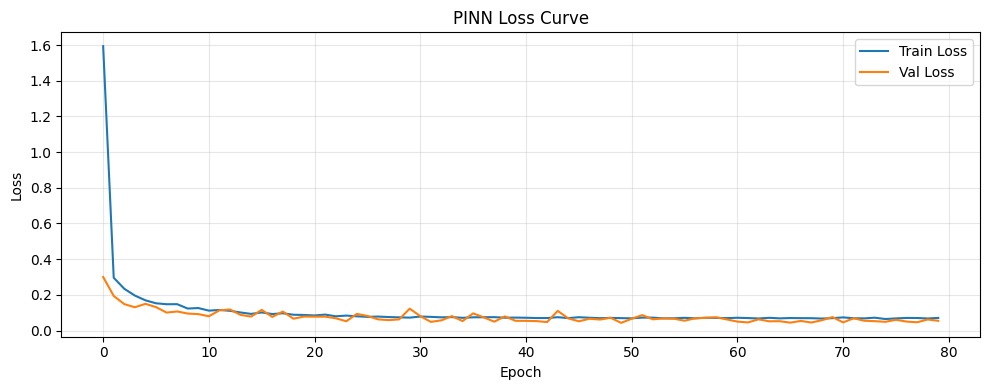

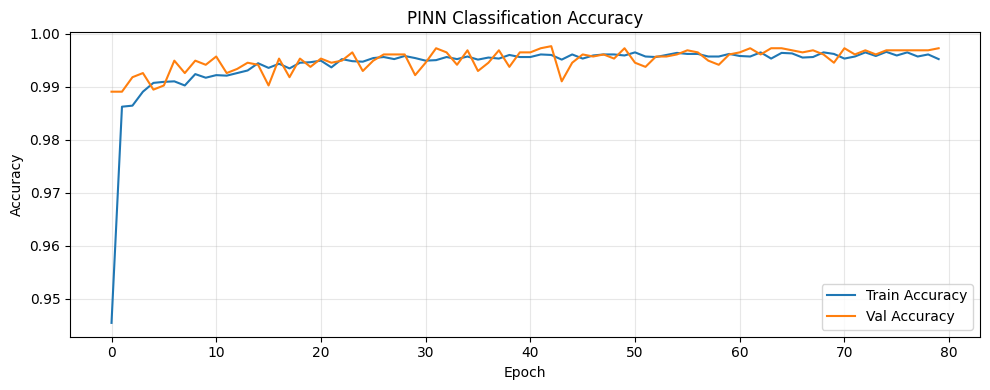

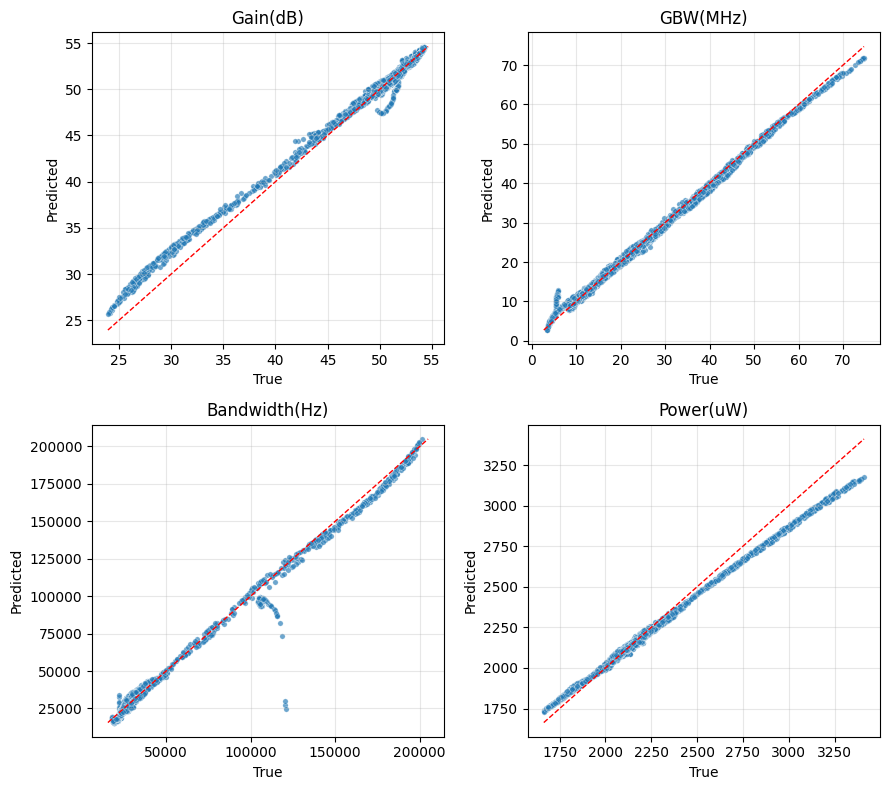

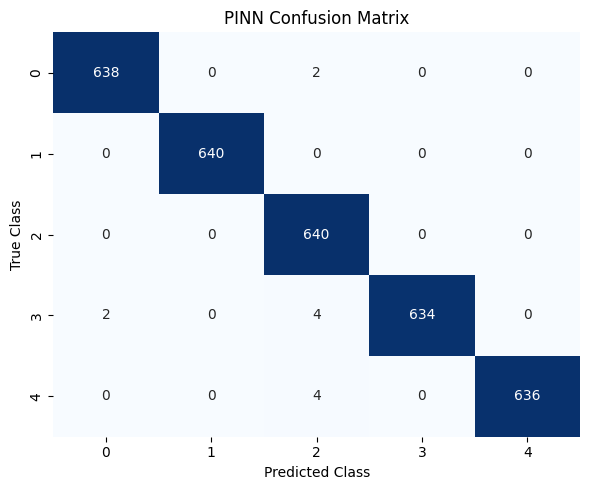

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

pinn.eval()
all_reg_preds = []
all_class_preds = []
all_reg_true = []
all_class_true = []

with torch.no_grad():
    for xb, yrb, ycb in test_loader:
        pr, pc = pinn(xb)
        all_reg_preds.append(pr.cpu().numpy())
        all_class_preds.append(torch.argmax(pc, dim=1).cpu().numpy())
        all_reg_true.append(yrb.cpu().numpy())
        all_class_true.append(ycb.cpu().numpy())

y_reg_pred_scaled = np.vstack(all_reg_preds)
y_reg_true_scaled = np.vstack(all_reg_true)
y_class_pred = np.concatenate(all_class_preds)
y_class_true_np = np.concatenate(all_class_true)

y_reg_pred = scaler_y_reg.inverse_transform(y_reg_pred_scaled)
y_reg_true = scaler_y_reg.inverse_transform(y_reg_true_scaled)

regression_rows = []
for i, target_name in enumerate(REGRESSION_TARGETS):
    y_true_col = y_reg_true[:, i]
    y_pred_col = y_reg_pred[:, i]
    regression_rows.append({
        'Target': target_name,
        'R2': r2_score(y_true_col, y_pred_col),
        'RMSE': np.sqrt(mean_squared_error(y_true_col, y_pred_col)),
        'MAE': mean_absolute_error(y_true_col, y_pred_col),
        'MAPE': mean_absolute_percentage_error(y_true_col, y_pred_col),
    })

df_reg_metrics = pd.DataFrame(regression_rows)
df_reg_summary = pd.DataFrame([
    {
        'Metric': 'Average',
        'R2': df_reg_metrics['R2'].mean(),
        'RMSE': df_reg_metrics['RMSE'].mean(),
        'MAE': df_reg_metrics['MAE'].mean(),
        'MAPE': df_reg_metrics['MAPE'].mean(),
    }
])

accuracy = accuracy_score(y_class_true_np, y_class_pred)
precision = precision_score(y_class_true_np, y_class_pred, average='weighted', zero_division=0)
recall = recall_score(y_class_true_np, y_class_pred, average='weighted', zero_division=0)
f1 = f1_score(y_class_true_np, y_class_pred, average='weighted', zero_division=0)
cm = confusion_matrix(y_class_true_np, y_class_pred)

C1, C2, C3 = 11.28, 0.133, 1e-6
idx_gain = REGRESSION_TARGETS.index('Gain(dB)')
idx_bw = REGRESSION_TARGETS.index('Bandwidth(Hz)')
idx_gbw = REGRESSION_TARGETS.index('GBW(MHz)')
idx_pm = REGRESSION_TARGETS.index('PM(degree)')

p_gain = y_reg_pred[:, idx_gain]
p_bw = y_reg_pred[:, idx_bw]
p_gbw = y_reg_pred[:, idx_gbw]
p_pm = y_reg_pred[:, idx_pm]
gain_lin = 10 ** (p_gain / 20.0)
pm_corr = C1 - (C2 * p_pm)
gbw_calc = gain_lin * p_bw * pm_corr * C3
consistency_r2 = r2_score(p_gbw, gbw_calc)
consistency_mape = mean_absolute_percentage_error(gbw_calc, p_gbw)
relative_violation = np.abs((p_gbw - gbw_calc) / (gbw_calc + 1e-8))
violation_mean = np.mean(relative_violation)
violation_std = np.std(relative_violation)
within_10_percent = np.mean(relative_violation <= 0.10) * 100

print('\nTEST SET PERFORMANCE METRICS')
print('=' * 80)
print('Regression metrics per target:')
print(df_reg_metrics.to_string(index=False))
print('\nAverage regression metrics:')
print(df_reg_summary.to_string(index=False))
print('\nClassification metrics:')
print(f'Accuracy : {accuracy:.4f}')
print(f'Precision : {precision:.4f}')
print(f'Recall    : {recall:.4f}')
print(f'F1 Score  : {f1:.4f}')
print('\nPhysics consistency metrics:')
print(f'GBW consistency R2   : {consistency_r2:.4f}')
print(f'GBW consistency MAPE : {consistency_mape:.4f}')
print(f'Mean violation       : {violation_mean:.4f}')
print(f'Std. violation        : {violation_std:.4f}')
print(f'% within ±10%        : {within_10_percent:.2f}%')

display(df_reg_metrics)
display(df_reg_summary)

plt.figure(figsize=(10, 4))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('PINN Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Val Accuracy')
plt.title('PINN Classification Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(9, 8))
targets_to_plot = ['Gain(dB)', 'GBW(MHz)', 'Bandwidth(Hz)', 'Power(uW)']
for ax, target_name in zip(axes.ravel(), targets_to_plot):
    idx = REGRESSION_TARGETS.index(target_name)
    ax.scatter(y_reg_true[:, idx], y_reg_pred[:, idx], alpha=0.65, s=15, edgecolor='white', linewidth=0.3)
    min_val = min(y_reg_true[:, idx].min(), y_reg_pred[:, idx].min())
    max_val = max(y_reg_true[:, idx].max(), y_reg_pred[:, idx].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1)
    ax.set_title(target_name)
    ax.set_xlabel('True')
    ax.set_ylabel('Predicted')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('PINN Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.tight_layout()
plt.show()